<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/CASO_REGRESION_POLINOMIAL_datos_publicacones_calidad_de_iunviersidades_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementar y evaluar modelo de regresión polinomial de segundo, tercer y quinto orden

# Contexto de los datos

El término calidad por si solo depende de muchas circunstancias; la calidad de educación de escuelas de nivel superior, dependen de muchas variables que arrojan los procesos internos académicos y administrativos, o tal vez de aspectos y variable de tipo políticos, sociales, económico entre otros.

Existen muchas variables que definen calidad en las universidades. Este caso se centra en una emulación de un conjunto de datos que relaciona la cantidad de publicaciones media de una universidad en relación a la calidad.

Se tienen dos variables:
* cantidad_publicacones es la cantidad promedo anual de publicacones de una univerisidad, siendo estos valores simulados.
* indice_calidad significa un valor numérico que se designa en que calidad está la universidad en un rango de 50 a 100.

Los datos se encuentran en el enlace de plataforma github del autor: https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/publicacones_calidad_universidades.csv

La cantidad de registros a analizar es alrededor de 1000 filas.



# Objetivo

Implementar y evaluar un modelo de regresión polinomial de primer, segundo, tercer y quinto orden con datos bivariados que definen calidad en educación superior.

# Descripción

## Cargar librerías



In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import scipy.stats as stats

from statsmodels.stats.stattools import durbin_watson

from sklearn.model_selection import train_test_split # Partir datos
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.pipeline import Pipeline
from statsmodels.nonparametric.smoothers_lowess import lowess




## Cargar funciones


In [60]:
# Funciones para ejecución del caso
def f_cargar_datos(ruta_archivo):
    #------------------------------------------------------------
    # Importar datos desde un archivo CSV.
    # Argumentos:
    #   ruta_archivo: ruta del archivo a cargar.
    # Retorna:
    #   DataFrame listo para análisis.
    #------------------------------------------------------------

    datos = pd.read_csv(ruta_archivo)
    return datos

def f_visualizar_head_tail_reducido_word(datos, n=10):
    #------------------------------------------------------------
    # Mostrar primeros n y últimos n registros en una sola tabla
    # con columnas reducidas:
    #   - primeras 4 columnas
    #   - últimas 3 columnas
    #------------------------------------------------------------

    total_columnas = datos.shape[1]

    idx_prim = list(range(min(4, total_columnas)))
    idx_ult = list(range(max(total_columnas - 3, 0), total_columnas))

    columnas = sorted(set(idx_prim + idx_ult))

    datos_reducidos = datos.iloc[:, columnas]

    head_datos = datos_reducidos.head(n).astype(str)
    tail_datos = datos_reducidos.tail(n).astype(str)

    fila_puntos = pd.DataFrame([["..."] * datos_reducidos.shape[1]],
                              columns=datos_reducidos.columns)

    tabla_final = pd.concat([head_datos, fila_puntos, tail_datos])

    return tabla_final

def f_describir_datos(datos):
    #------------------------------------------------------------
    # Generar estadísticas descriptivas básicas
    #------------------------------------------------------------

    describe = datos.describe()

    structure = datos.info()

    return {
        "describe": describe,
        "structure": structure
    }

def f_particionar_datos(datos, proporcion_entrenamiento=0.7):
    #------------------------------------------------------------
    # Dividir dataset en entrenamiento y validación
    #------------------------------------------------------------

    train, test = train_test_split(
        datos,
        train_size=proporcion_entrenamiento,
        random_state=2026
    )

    return {
        "datos_entrenamiento": train,
        "datos_validacion": test
    }



def f_construir_modelo(datos_entrenamiento, variable_independiente, variable_dependiente, grado=1):
    #------------------------------------------------------------
    # Construir modelo de regresión lineal o polinómico
    # usando Pipeline (evita warnings automáticamente)
    #------------------------------------------------------------

    X = datos_entrenamiento[[variable_independiente]]
    y = datos_entrenamiento[variable_dependiente]

    modelo = Pipeline([
        ("poly", PolynomialFeatures(degree=grado, include_bias=False)),
        ("lr", LinearRegression())
    ])

    modelo.fit(X, y)

    # metadatos útiles
    modelo.grado = grado
    modelo.variable_x = variable_independiente

    return modelo


def f_diagrama_dispersion_tendencia(modelo, datos, x, y):

    x_vals = datos[x]
    y_vals = datos[y]

    # correlación
    r = np.corrcoef(x_vals, y_vals)[0,1]

    # predicción directa (Pipeline ya gestiona todo)
    y_pred = modelo.predict(datos[[x]])

    r2 = r2_score(y_vals, y_pred)

    plt.figure(figsize=(8,6))

    # dispersión
    plt.scatter(x_vals, y_vals, alpha=0.6)

    # ordenar X
    x_sorted = np.sort(x_vals.values)
    x_sorted_df = pd.DataFrame(x_sorted, columns=[x])

    y_line = modelo.predict(x_sorted_df)

    # curva
    plt.plot(x_sorted, y_line, color='red', linewidth=2,
             label=f"Grado {modelo.grado}")

    plt.title("Dispersión y tendencia")
    plt.suptitle(f"{x} vs {y} ; r={r:.3f} ; R²={r2:.3f}")

    plt.xlabel(x)
    plt.ylabel(y)

    plt.legend()

    plt.show()

def f_diagrama_dispersion_matriz(modelos, datos, x, y, titulos=None):

    if len(modelos) != 4:
        raise ValueError("Debes proporcionar exactamente 4 modelos")

    if titulos is None:
        titulos = [f"Modelo {i+1}" for i in range(4)]

    x_vals = datos[x]
    y_vals = datos[y]

    r = np.corrcoef(x_vals, y_vals)[0,1]

    fig, axes = plt.subplots(2, 2, figsize=(12,10))
    axes = axes.flatten()

    for i, modelo in enumerate(modelos):

        ax = axes[i]

        ax.scatter(x_vals, y_vals, alpha=0.5)

        x_sorted = np.sort(x_vals.values)
        x_sorted_df = pd.DataFrame(x_sorted, columns=[x])

        y_pred = modelo.predict(datos[[x]])
        y_line = modelo.predict(x_sorted_df)

        r2 = r2_score(y_vals, y_pred)

        ax.plot(x_sorted, y_line, color='red', linewidth=2)

        ax.set_title(f"{titulos[i]}\nr={r:.3f} ; R²={r2:.3f}")
        ax.set_xlabel(x)
        ax.set_ylabel(y)

    plt.tight_layout()
    plt.show()

def f_ecuaciones_modelos(modelos, nombres_modelos=None):
    #------------------------------------------------------------
    # f_ecuaciones_modelos()
    #
    # Objetivo:
    #   Mostrar ecuaciones matemáticas y coeficientes
    #   de múltiples modelos (lineal y polinomiales)
    #
    # Argumentos:
    #   modelos          : lista de modelos
    #   nombres_modelos  : nombres de los modelos
    #
    #------------------------------------------------------------

    if nombres_modelos is None:
        nombres_modelos = [f"Modelo {i+1}" for i in range(len(modelos))]

    for modelo, nombre in zip(modelos, nombres_modelos):

        print("\n" + "="*60)
        print(f" {nombre}")
        print("="*60)

        # extraer pipeline
        poly = modelo.named_steps["poly"]
        lr = modelo.named_steps["lr"]

        nombres_vars = poly.get_feature_names_out([modelo.variable_x])
        coeficientes = lr.coef_
        intercepto = lr.intercept_

        #--------------------------------------------------------
        # Mostrar coeficientes
        #--------------------------------------------------------
        print("\nCoeficientes del modelo:")
        print(f"Intercepto: {round(intercepto,4)}")

        for nombre_var, coef in zip(nombres_vars, coeficientes):
            print(f"{nombre_var}: {round(coef,4)}")

        #--------------------------------------------------------
        # Construir ecuación
        #--------------------------------------------------------
        ecuacion = f"ŷ = {round(intercepto,4)}"

        for c, nombre_var in zip(coeficientes, nombres_vars):
            signo = "+" if c >= 0 else "-"
            ecuacion += f" {signo} {abs(round(c,4))}·{nombre_var}"

        print("\nEcuación del modelo:")
        print(ecuacion)

def f_evaluar_modelo(modelo, datos_validacion, variable_dependiente, variable_independiente):

    #------------------------------------------------------------
    # 1. Datos
    #------------------------------------------------------------
    X = datos_validacion[[variable_independiente]]
    y_real = datos_validacion[variable_dependiente]

    #------------------------------------------------------------
    # 2. Predicción (Pipeline ya maneja polinomio)
    #------------------------------------------------------------
    pred = modelo.predict(X)

    #------------------------------------------------------------
    # 3. Métricas
    #------------------------------------------------------------
    mse = mean_squared_error(y_real, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, pred)

    #------------------------------------------------------------
    # 4. Número de parámetros (p)
    #------------------------------------------------------------
    if hasattr(modelo, "named_steps"):
        poly = modelo.named_steps["poly"]
        p = len(poly.get_feature_names_out())
    else:
        p = 1

    n = len(y_real)

    #------------------------------------------------------------
    # 5. R² ajustado
    #------------------------------------------------------------
    r2_adj = 1 - (1 - r2)*(n - 1)/(n - p - 1)

    #------------------------------------------------------------
    # 6. Resultado
    #------------------------------------------------------------
    resultado = pd.DataFrame({
        "R_square": [round(r2,4)],
        "R_square_ajustado": [round(r2_adj,4)],
        "MSE": [round(mse,4)],
        "RMSE": [round(rmse,4)],
        "Parametros (p)": [p]
    })

    return resultado

# función que evalúa varios modelos al mismo tiempo jerarquiza ordenando con RMSE
# y devuelve una tabla
# Recibe el modelo, los datos de validación,
# las variables independiente y dependiente y el nombre del modelo
# Manda llamar f_evaluar_modelo() que evalua un modelo a la vez
def f_evaluar_modelos_varios(modelos, datos_validacion, y, x, nombres_modelos=None):

    if nombres_modelos is None:
        nombres_modelos = [f"Modelo {i+1}" for i in range(len(modelos))]

    resultados = []

    for modelo, nombre in zip(modelos, nombres_modelos):

        res = f_evaluar_modelo(modelo, datos_validacion, y, x)
        res["Modelo"] = nombre

        resultados.append(res)

    df_final = pd.concat(resultados, ignore_index=True)

    # ordenar por mejor RMSE
    df_final = df_final.sort_values(by="RMSE")

    return df_final


# Funciones para validar el modelo con los supuestos
# del modelo polinomial
def f_verificar_linealidad(datos, x, y):
    #------------------------------------------------------------
    # Evaluar relación entre variables mediante scatter plot
    #------------------------------------------------------------

    plt.figure(figsize=(8,6))
    plt.scatter(datos[x], datos[y], alpha=0.6)

    plt.title("Verificación de linealidad")
    plt.xlabel(x)
    plt.ylabel(y)

    plt.show()

def f_matriz_verificar_homocedasticidad(modelos, datos, x, y, nombres_modelos=None):
    #------------------------------------------------------------
    # Visualización 2x2 de residuos con curva suavizada (LOWESS)
    #------------------------------------------------------------

    if len(modelos) != 4:
        raise ValueError("Debes proporcionar exactamente 4 modelos")

    if nombres_modelos is None:
        nombres_modelos = [f"Modelo {i+1}" for i in range(4)]

    fig, axes = plt.subplots(2, 2, figsize=(12,10))
    axes = axes.flatten()

    for i, modelo in enumerate(modelos):

        ax = axes[i]

        # valores reales
        y_real = datos[y]

        # predicción
        if hasattr(modelo, "poly"):
            X_poly = modelo.poly.transform(datos[[x]])
            y_pred = modelo.predict(X_poly)
        else:
            y_pred = modelo.predict(datos[[x]])

        # residuos
        residuos = y_real - y_pred

        # scatter
        ax.scatter(y_pred, residuos, alpha=0.5)

        # línea horizontal en cero
        ax.axhline(y=0, linestyle='--')

        #--------------------------------------------------------
        # 🔥 CURVA SUAVIZADA (LOWESS)
        #--------------------------------------------------------
        curva = lowess(residuos, y_pred, frac=0.3)

        ax.plot(curva[:,0], curva[:,1],
                linewidth=2,
                alpha=0.4,
                linestyle='-')

        #--------------------------------------------------------
        # 🔥 BANDA VISUAL (opcional tipo nube)
        #--------------------------------------------------------
        std = np.std(residuos)

        ax.fill_between(
            np.sort(y_pred),
            -2*std,
            2*std,
            alpha=0.05
        )

        # títulos
        ax.set_title(nombres_modelos[i])
        ax.set_xlabel("Valores ajustados")
        ax.set_ylabel("Residuos")

    plt.tight_layout()
    plt.show()

def f_matriz_normalidad_modelos(modelos, datos, x, y, nombres_modelos=None):
    #------------------------------------------------------------
    # f_matriz_normalidad_modelos()
    #
    # Objetivo:
    #   Evaluar normalidad de residuos en 4 modelos:
    #   - Histograma + densidad
    #   - Q-Q plot
    #   - Shapiro-Wilk
    #   - Ranking automático
    #
    #------------------------------------------------------------


    if len(modelos) != 4:
        raise ValueError("Debes proporcionar exactamente 4 modelos")

    if nombres_modelos is None:
        nombres_modelos = [f"Modelo {i+1}" for i in range(4)]

    resultados = []

    fig, axes = plt.subplots(4, 2, figsize=(12,16))

    for i, modelo in enumerate(modelos):

        #--------------------------------------------------------
        # Predicciones
        #--------------------------------------------------------
        if hasattr(modelo, "poly"):
            X_poly = modelo.poly.transform(datos[[x]])
            y_pred = modelo.predict(X_poly)
        else:
            y_pred = modelo.predict(datos[[x]])

        y_real = datos[y]
        residuos = y_real - y_pred

        #--------------------------------------------------------
        # Shapiro-Wilk
        #--------------------------------------------------------
        W, p_value = stats.shapiro(residuos)

        if p_value > 0.05:
            interpretacion = "Normal"
        else:
            interpretacion = "No normal"

        # guardar resultados
        resultados.append({
            "Modelo": nombres_modelos[i],
            "W": W,
            "p_value": p_value,
            "Normalidad": interpretacion
        })

        #--------------------------------------------------------
        # Gráficos
        #--------------------------------------------------------

        # Histograma
        sns.histplot(residuos, kde=True, ax=axes[i,0])
        axes[i,0].set_title(
            f"{nombres_modelos[i]}\nHistograma\n"
            f"W={W:.3f} | p={p_value:.3f} | {interpretacion}"
        )

        # Q-Q plot
        stats.probplot(residuos, dist="norm", plot=axes[i,1])
        axes[i,1].set_title(
            f"{nombres_modelos[i]}\nQ-Q Plot\n"
            f"W={W:.3f} | p={p_value:.3f} | {interpretacion}"
        )

    plt.tight_layout()
    plt.show()

    #------------------------------------------------------------
    # DataFrame de resultados
    #------------------------------------------------------------
    df_resultados = pd.DataFrame(resultados)

    #------------------------------------------------------------
    # Ranking (mejor normalidad = mayor p-value)
    #------------------------------------------------------------
    df_resultados["Ranking"] = df_resultados["p_value"].rank(ascending=False)

    df_resultados = df_resultados.sort_values(by="Ranking")

    return df_resultados


def f_verificar_independencia_residuos(modelos, datos, x, y, nombres_modelos=None, graficar=True):
    #------------------------------------------------------------
    # f_verificar_independencia_residuos()
    #
    # Objetivo:
    #   Evaluar independencia de residuos mediante:
    #   - Prueba Durbin-Watson
    #   - Interpretación automática
    #   - (Opcional) gráfico de residuos vs orden
    #
    # Argumentos:
    #   modelos         : lista de modelos (4)
    #   datos           : DataFrame
    #   x               : variable independiente
    #   y               : variable dependiente
    #   nombres_modelos : nombres de los modelos
    #   graficar        : True/False
    #
    # Retorna:
    #   DataFrame con resultados y ranking
    #------------------------------------------------------------


    if len(modelos) != 4:
        raise ValueError("Debes proporcionar exactamente 4 modelos")

    if nombres_modelos is None:
        nombres_modelos = [f"Modelo {i+1}" for i in range(4)]

    resultados = []

    if graficar:
        fig, axes = plt.subplots(2, 2, figsize=(12,8))
        axes = axes.flatten()

    for i, modelo in enumerate(modelos):

        #--------------------------------------------------------
        # Predicción
        #--------------------------------------------------------
        if hasattr(modelo, "poly"):
            X_poly = modelo.poly.transform(datos[[x]])
            y_pred = modelo.predict(X_poly)
        else:
            y_pred = modelo.predict(datos[[x]])

        y_real = datos[y]
        residuos = y_real - y_pred

        #--------------------------------------------------------
        # Durbin-Watson
        #--------------------------------------------------------
        dw = durbin_watson(residuos)

        # interpretación
        if 1.5 <= dw <= 2.5:
            interpretacion = "Independencia (sin autocorrelación)"
        elif dw < 1.5:
            interpretacion = "Autocorrelación positiva"
        else:
            interpretacion = "Autocorrelación negativa"

        resultados.append({
            "Modelo": nombres_modelos[i],
            "Durbin_Watson": dw,
            "Interpretacion": interpretacion
        })

        #--------------------------------------------------------
        # Gráfico (opcional)
        #--------------------------------------------------------
        if graficar:
            ax = axes[i]

            ax.plot(residuos, marker='o', alpha=0.6)
            ax.axhline(y=0, linestyle='--')

            ax.set_title(
                f"{nombres_modelos[i]}\nDW={dw:.3f}\n{interpretacion}"
            )
            ax.set_xlabel("Orden")
            ax.set_ylabel("Residuo")

    if graficar:
        plt.tight_layout()
        plt.show()

    #------------------------------------------------------------
    # DataFrame resultados
    #------------------------------------------------------------
    df_resultados = pd.DataFrame(resultados)

    #------------------------------------------------------------
    # Ranking (más cercano a 2 es mejor)
    #------------------------------------------------------------
    df_resultados["Distancia_2"] = abs(df_resultados["Durbin_Watson"] - 2)
    df_resultados["Ranking"] = df_resultados["Distancia_2"].rank()

    df_resultados = df_resultados.sort_values("Ranking")

    return df_resultados


## Cargar funciones


In [61]:
# Aqui se carga el archivo .py que contiene las funciones


## Cargar datos

Con la función *f_cargar_datos()* y como argumento la ruta en donde están los datos originales que se cargan a memoria de la plataforma google collab o similar para su análisis y uso en los modelos predictivos polinomiales.


In [62]:
datos = f_cargar_datos("https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/publicacones_calidad_universidades.csv")

## Visualizar datos

Ejecutando la función *f_visualizar_head_tail_reducido_word()* se observan los primeros y últimos registros del conjunto de datos.

Se observa la relación que hay entre publicacones anuales y calidad de universidad.

In [63]:
f_visualizar_head_tail_reducido_word(datos)

,id_universidad,publicaciones_anuales,indice_calidad
0,1,228,82.8
1,2,571,100.0
2,3,441,99.91
3,4,361,95.05
4,5,98,69.37
5,6,98,70.93
6,7,40,60.11
7,8,520,100.0
8,9,363,93.11
9,10,426,92.83


## Describir datos

Ejecutando la función *f_describir_datos()* se identifican los estadísticos descriptivos de los mismos.

Siendo las variables de interés *publicaciones_anuales* e *indice_calidad*, la media de las publicaciones es alrededor de *296* con una desviación estándar de *173*; mientras que la calidad media está en *84* con una desviación estándar de *14* aproximadamente.

In [64]:
f_describir_datos(datos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_universidad         1000 non-null   int64  
 1   publicaciones_anuales  1000 non-null   int64  
 2   indice_calidad         1000 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 23.6 KB


{'describe':        id_universidad  publicaciones_anuales  indice_calidad
 count     1000.000000            1000.000000     1000.000000
 mean       500.500000             296.703000       84.679460
 std        288.819436             173.827981       14.777371
 min          1.000000               8.000000       50.000000
 25%        250.750000             145.250000       73.472500
 50%        500.500000             300.500000       88.690000
 75%        750.250000             448.250000       99.162500
 max       1000.000000             600.000000      100.000000,
 'structure': None}

# Desarrollo

## Partición de los datos

* 70% datos de entranmiento
* 30% datos de validación

Se ejecuta la función  *f_particionar_datos()* y se observan los proimeros y últimos registros de los conjuntos de datos de entrenamiento y datos de validación.

In [65]:
# Particionar datos
particion = f_particionar_datos(datos)

datos_entrenamiento = particion["datos_entrenamiento"]
datos_validacion = particion["datos_validacion"]

f_visualizar_head_tail_reducido_word(datos_entrenamiento)


,id_universidad,publicaciones_anuales,indice_calidad
227,228,239,85.18
847,848,598,100.0
962,963,151,74.62
849,850,359,95.63
567,568,265,88.41
260,261,371,98.98
147,148,304,89.96
375,376,195,82.11
926,927,165,77.97
285,286,26,51.02


In [66]:
f_visualizar_head_tail_reducido_word(datos_validacion)

,id_universidad,publicaciones_anuales,indice_calidad
246,247,260,85.24
132,133,76,65.21
597,598,108,72.15
134,135,566,100.0
237,238,19,50.9
145,146,27,50.0
92,93,458,95.76
577,578,556,100.0
924,925,258,86.2
472,473,31,50.0


## Modelo de regresión polinomial (MRP)

Se construye el modelo de regresión polnomial de primer, segundo, tercer y quinto orden respectivamente.

Se ejecuta la función *f_construir_modelo* con los argumentos que corresponden a los datos de entrenamiento, y los nombres de las variables independiebnte y dependiebnte respectivamente *publicaciones_anuales* e *indice_calidad*.

La función regresa el modelo construido y los aloja respecitamente nombres de variables diferentes: *modelo_RP1*, *modelo_RP2*, *modelo_RP3* y *modelo_RP5*.

A partir de cada modelo se validan los supuestos del mismo.




In [67]:
# modelo lineal primer orden
modelo_RP1 = f_construir_modelo(datos_entrenamiento, "publicaciones_anuales", "indice_calidad", grado=1)

# modelo lineal segundo orden
modelo_RP2 = f_construir_modelo(datos_entrenamiento, "publicaciones_anuales", "indice_calidad", grado=2)

# modelo lineal tercer orden
modelo_RP3 = f_construir_modelo(datos_entrenamiento, "publicaciones_anuales", "indice_calidad", grado=3)

# modelo lineal quinto orden
modelo_RP5 = f_construir_modelo(datos_entrenamiento, "publicaciones_anuales", "indice_calidad", grado=5)



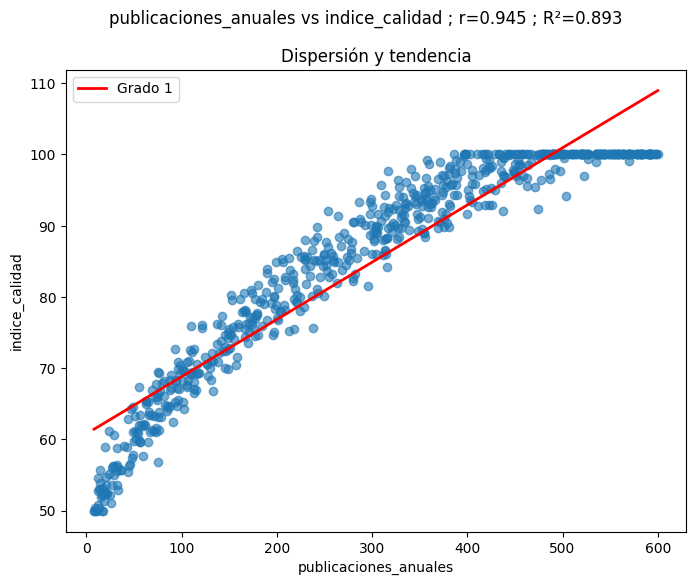

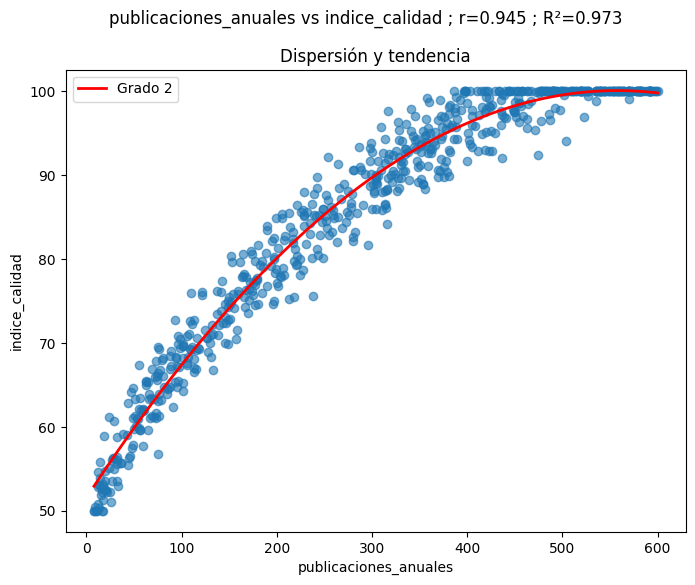

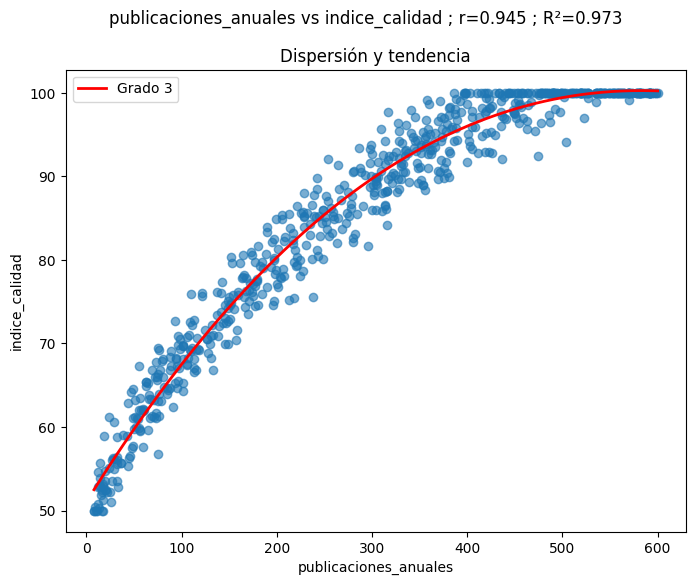

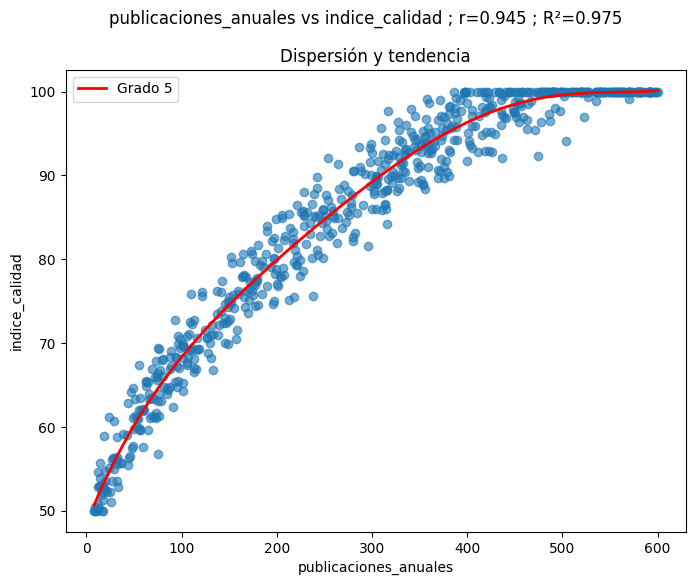

In [68]:
f_diagrama_dispersion_tendencia(modelo_RP1, datos_entrenamiento, "publicaciones_anuales", "indice_calidad")
f_diagrama_dispersion_tendencia(modelo_RP2, datos_entrenamiento, "publicaciones_anuales", "indice_calidad")
f_diagrama_dispersion_tendencia(modelo_RP3, datos_entrenamiento, "publicaciones_anuales", "indice_calidad")
f_diagrama_dispersion_tendencia(modelo_RP5, datos_entrenamiento, "publicaciones_anuales", "indice_calidad")


## Supuestos del modelo

Se asegura cumplir con los supuestos del modelo.

* Linealidad y/o relación Gráficos  de Dispersión (Scatter plot).
* Homocedasticidad Gráfico de Residuos vs. Valores Ajustados.
* Normalidad de residuos Histograma de residuos o Q-Q Plot.
* Independencia Prueba de Durbin-Watson.
* Multicolinealidad mediante el Factor de Inflación de la Varianza (VIF). No aplica en datos bivariados.

Para validar los supuestos del modelo de regresión polinomial, se implementaron diversas funciones que permiten evaluar gráficamente y estadísticamente la linealidad, homocedasticidad, normalidad de los residuos, independencia y multicolinealidad.

Estas verificaciones son fundamentales para garantizar la validez de las inferencias derivadas del modelo

### Linealidad

Se ejecuta la función f_verificar_linealidad() para observar la relación no en línea recta sino que hay una relación curva entre publicaciones anuales e índice de calidad de la universidad.

De igual manera con la función f_diagrama_dispersion_matriz() que produce un matriz con cuatro dispersiones de los datos de entrenamiento en la que se observa que existe linealidad entre las dos variables.

La pregunta es ¿Cuál modelo aplicar?, pues definitivamente la relación no es en línea recta sino que es curvilinea de lo cual se desprende que los modelos a utilizar son los polinomiales.

Y luego, ¿de cuál orden implementar el modelo polinomial?, pues la respuesta depende de la calidad y rigor del modelo además si con el modelo polinomial de segundo orden es suficiente, tal vez no sea necesario generar complejidad en los modelos, pero eso es parte y arte y quehacer ordinario de un científico de datos en el ámbito del aprendizaje automático.



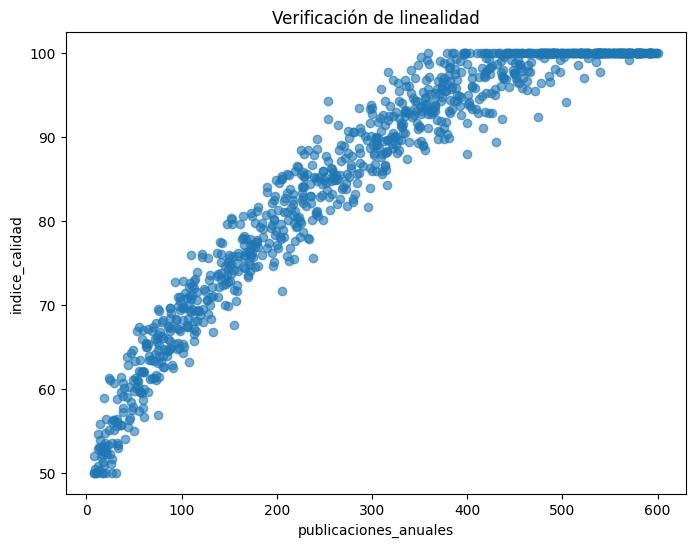

In [69]:
f_verificar_linealidad(datos, "publicaciones_anuales", "indice_calidad")

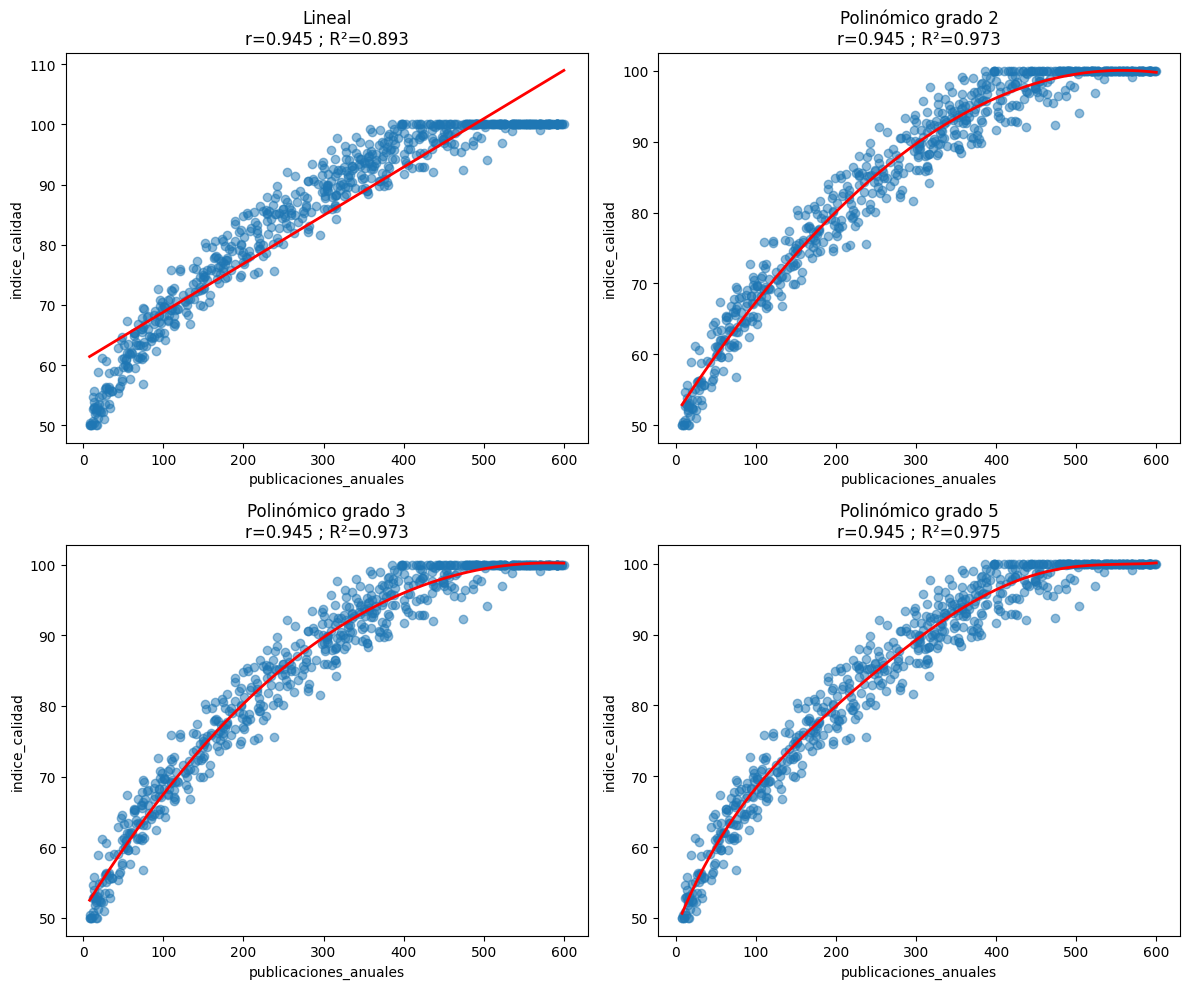

In [70]:
modelos = [modelo_RP1, modelo_RP2, modelo_RP3, modelo_RP5]

titulos = [
    "Lineal",
    "Polinómico grado 2",
    "Polinómico grado 3",
    "Polinómico grado 5"
]

f_diagrama_dispersion_matriz(
    modelos,
    datos_entrenamiento,
    "publicaciones_anuales",
    "indice_calidad",
    titulos
)

### Homocestacidad



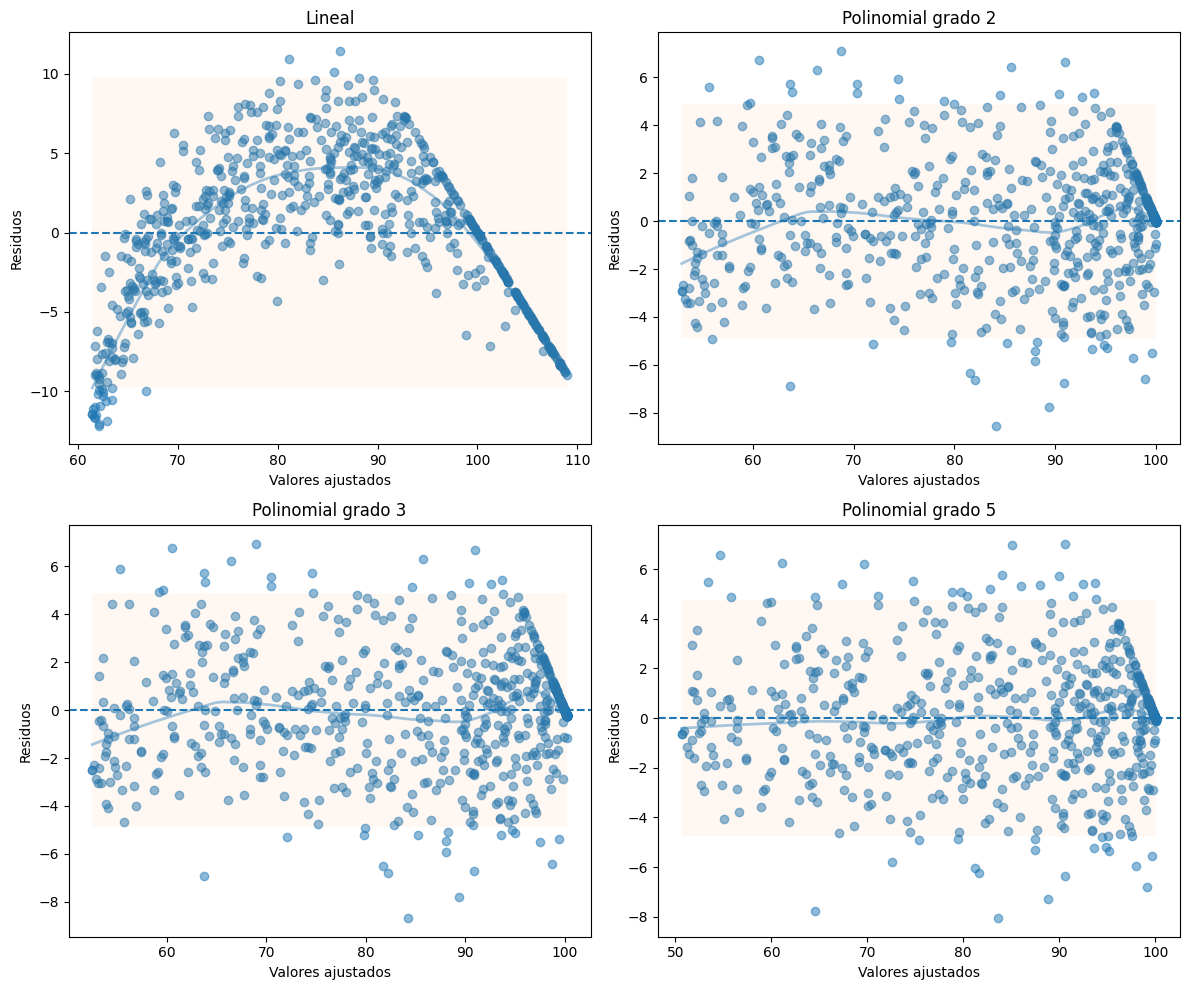

In [71]:
modelos = [modelo_RP1, modelo_RP2, modelo_RP3, modelo_RP5]

nombres = [
    "Lineal",
    "Polinomial grado 2",
    "Polinomial grado 3",
    "Polinomial grado 5"
]

f_matriz_verificar_homocedasticidad(
    modelos,
    datos_entrenamiento,
    "publicaciones_anuales",
    "indice_calidad",
    nombres
)

### Normalidad de residuos

Se ejecuta la función *f_matriz_normalidad_modelos* que valora la normalidad de los residuos de los cuatro modelos.



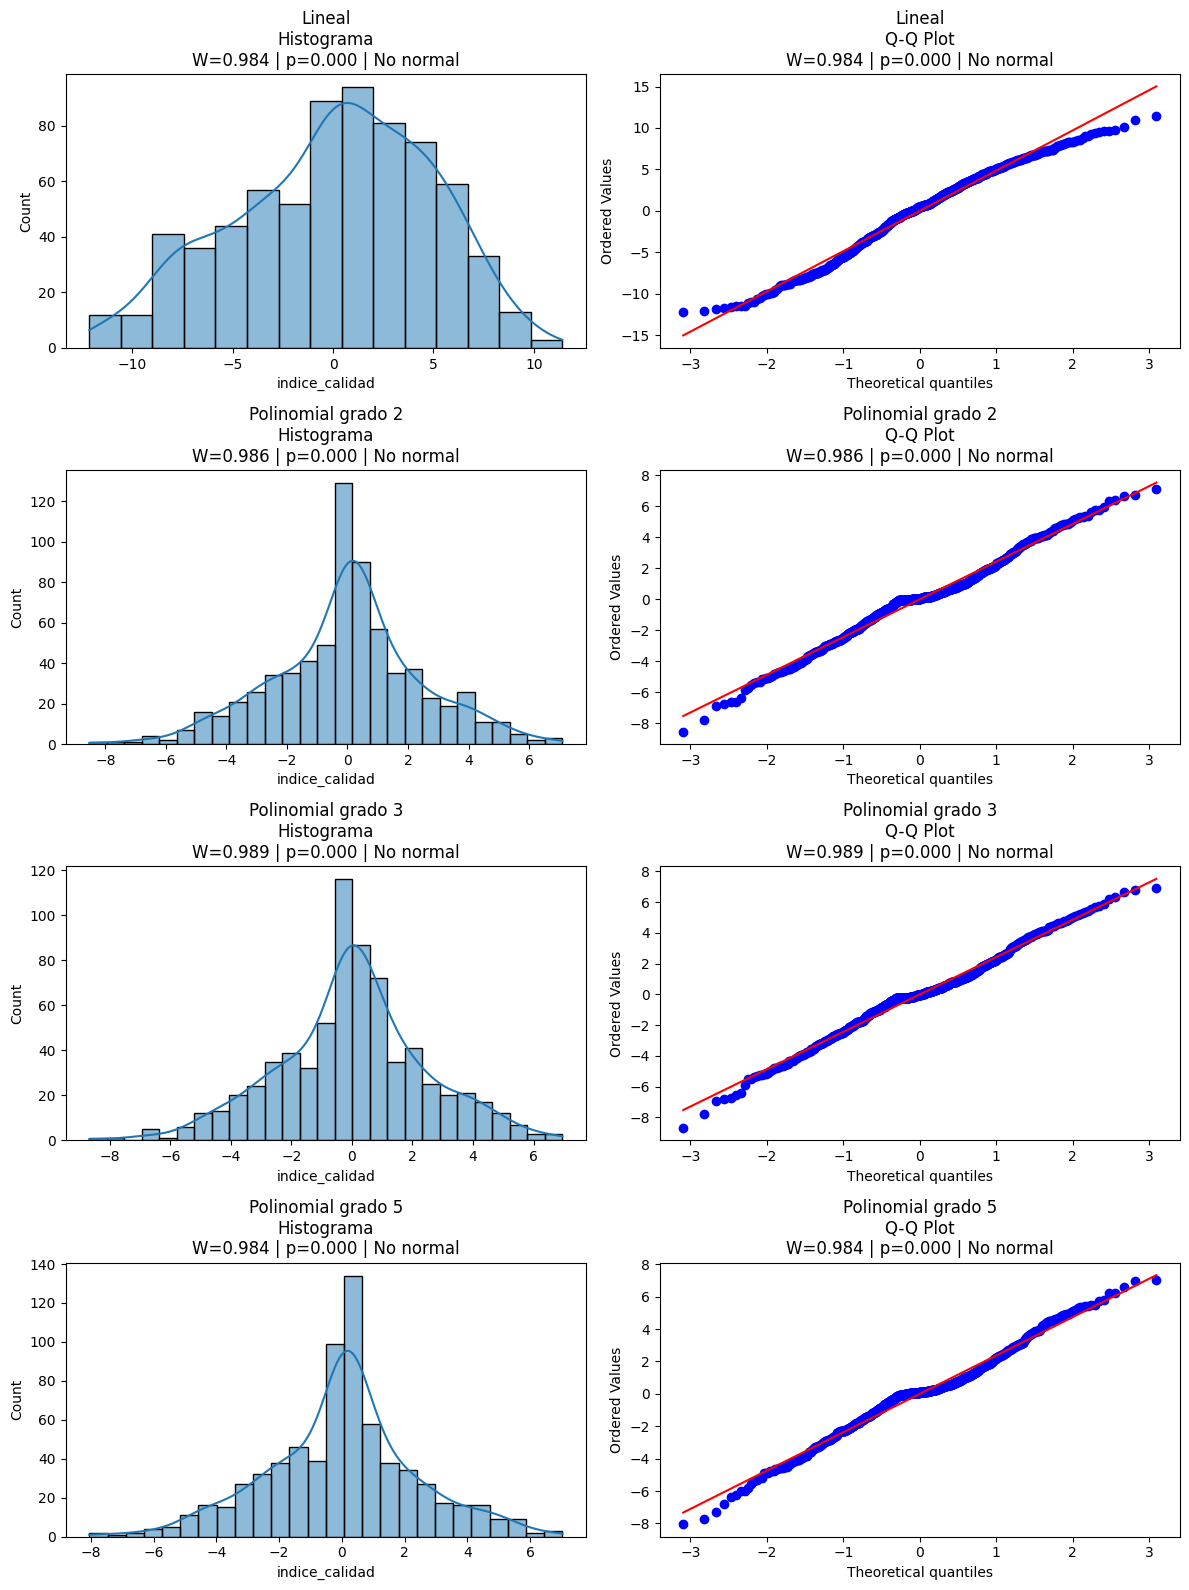

               Modelo         W       p_value Normalidad  Ranking
2  Polinomial grado 3  0.989429  6.219319e-05  No normal      1.0
1  Polinomial grado 2  0.986488  4.578723e-06  No normal      2.0
3  Polinomial grado 5  0.983680  4.871126e-07  No normal      3.0
0              Lineal  0.983605  4.600364e-07  No normal      4.0


In [72]:
modelos = [modelo_RP1, modelo_RP2, modelo_RP3, modelo_RP5]

nombres = [
    "Lineal",
    "Polinomial grado 2",
    "Polinomial grado 3",
    "Polinomial grado 5"
]

ranking = f_matriz_normalidad_modelos(
    modelos,
    datos_entrenamiento,
    "publicaciones_anuales",
    "indice_calidad",
    nombres
)

print(ranking)


### Independencia de residuos



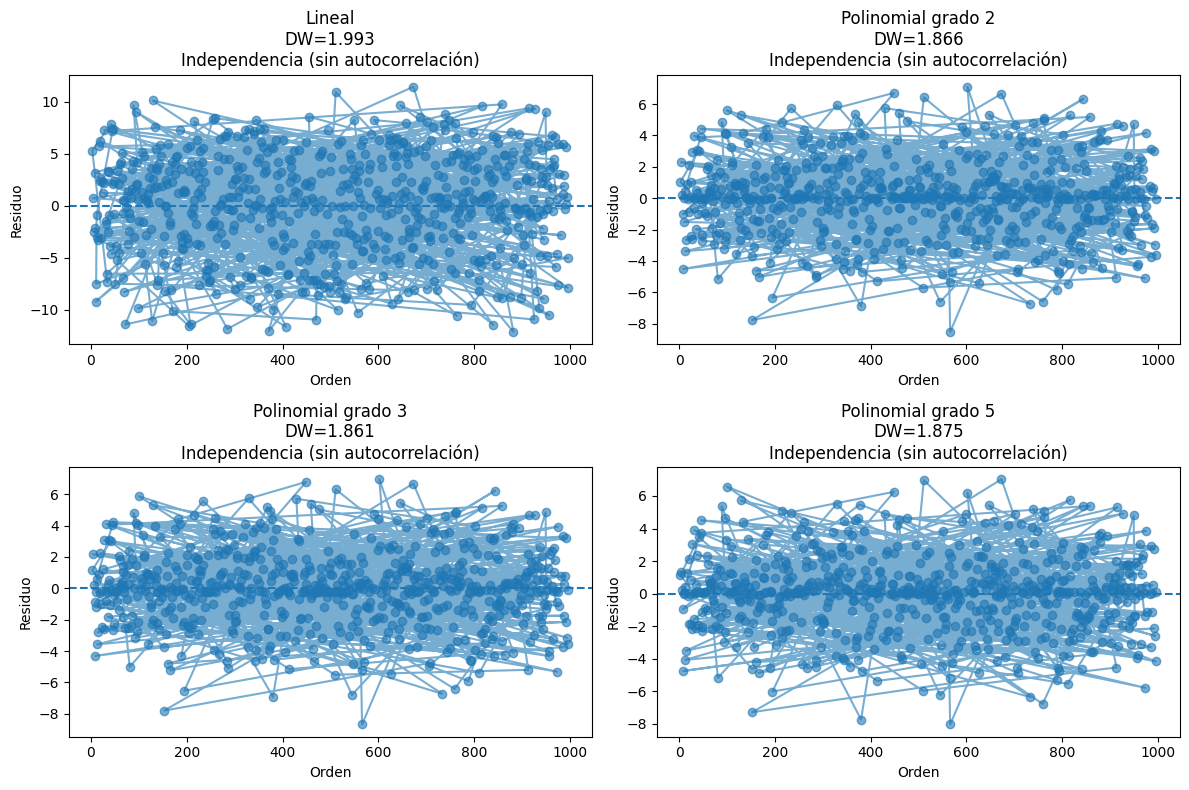

               Modelo  Durbin_Watson                       Interpretacion  \
0              Lineal       1.993128  Independencia (sin autocorrelación)   
3  Polinomial grado 5       1.874712  Independencia (sin autocorrelación)   
1  Polinomial grado 2       1.866386  Independencia (sin autocorrelación)   
2  Polinomial grado 3       1.861196  Independencia (sin autocorrelación)   

   Distancia_2  Ranking  
0     0.006872      1.0  
3     0.125288      2.0  
1     0.133614      3.0  
2     0.138804      4.0  


In [73]:
modelos = [modelo_RP1, modelo_RP2, modelo_RP3, modelo_RP5]

nombres = [
    "Lineal",
    "Polinomial grado 2",
    "Polinomial grado 3",
    "Polinomial grado 5"
]

resultado_dw = f_verificar_independencia_residuos(
    modelos,
    datos_entrenamiento,
    "publicaciones_anuales",
    "indice_calidad",
    nombres
)

print(resultado_dw)

### Coeficientes de los modelos



In [74]:
modelos = [modelo_RP1, modelo_RP2, modelo_RP3, modelo_RP5]

nombres = [
    "Regresión lineal (grado 1)",
    "Polinomial grado 2",
    "Polinomial grado 3",
    "Polinomial grado 4"
]

f_ecuaciones_modelos(modelos, nombres)


 Regresión lineal (grado 1)

Coeficientes del modelo:
Intercepto: 60.7822
publicaciones_anuales: 0.0803

Ecuación del modelo:
ŷ = 60.7822 + 0.0803·publicaciones_anuales

 Polinomial grado 2

Coeficientes del modelo:
Intercepto: 51.5247
publicaciones_anuales: 0.174
publicaciones_anuales^2: -0.0002

Ecuación del modelo:
ŷ = 51.5247 + 0.174·publicaciones_anuales - 0.0002·publicaciones_anuales^2

 Polinomial grado 3

Coeficientes del modelo:
Intercepto: 51.0425
publicaciones_anuales: 0.1835
publicaciones_anuales^2: -0.0002
publicaciones_anuales^3: 0.0

Ecuación del modelo:
ŷ = 51.0425 + 0.1835·publicaciones_anuales - 0.0002·publicaciones_anuales^2 + 0.0·publicaciones_anuales^3

 Polinomial grado 4

Coeficientes del modelo:
Intercepto: 48.4427
publicaciones_anuales: 0.2838
publicaciones_anuales^2: -0.0012
publicaciones_anuales^3: 0.0
publicaciones_anuales^4: -0.0
publicaciones_anuales^5: 0.0

Ecuación del modelo:
ŷ = 48.4427 + 0.2838·publicaciones_anuales - 0.0012·publicaciones_anuales^2 +

## Evaluación de modelos

Se ejecuta la función

In [75]:
f_evaluar_modelo(modelo_RP1, datos_validacion, "indice_calidad", "publicaciones_anuales")

,R_square,R_square_ajustado,MSE,RMSE,Parametros (p)
0,0.8925,0.8921,22.204,4.7121,1


In [77]:
modelos = [modelo_RP1, modelo_RP2, modelo_RP3, modelo_RP5]

nombres = [
    "Lineal",
    "Polinomial grado 2",
    "Polinomial grado 3",
    "Polinomial grado 5"
]

resultado = f_evaluar_modelos_varios(
    modelos,
    datos_validacion,
    "indice_calidad",
    "publicaciones_anuales",
    nombres
)

resultado

,R_square,R_square_ajustado,MSE,RMSE,Parametros (p),Modelo
3,0.9632,0.9626,7.5904,2.7551,5,Polinomial grado 5
2,0.9616,0.9613,7.9202,2.8143,3,Polinomial grado 3
1,0.9616,0.9614,7.9227,2.8147,2,Polinomial grado 2
0,0.8925,0.8921,22.2040,4.7121,1,Lineal


# Interpretación

El caso de estudio implementó y evaluó cuatro modelos polinomoales con datos bivariados que estiman la calidad de una escuela de educación superior.

Los datos contienen alrededor de mil registros con dos variables de interés: publicaciones_anuales como variable independiente e índice_calidad como variable dependiente.

Se cargaron librerías y funciones necesarias para la correcta ejecución de este caso de estudio.

Se construyeron cuatro modelos de regresión de primer orden o lineal recta y polinomiales de segundo, tercer y quinto orden

Se hizo una partición del 70% para datos de entrenamiento y 30% para datos de validación.

Los modelos polinomiales de segundo, tercer y quinto grado, cumplen con los supuestos de linealidad, homocedasticidad, una normalidad visualmente hablando mas no pasaron la prueba de Shapiro-Wilk y también cumplen con los criterios de independencia de los residuos con la prueba de Durbin-Watson con valores muy cercanos a 2.

Es evidente con los supuestos que los mejores modelos para realizar predicciones con estos datos son los modelos polinomiales de segundo, tercer y quinto grado y no así el modelo de primer orden o línea recta.

La eficiencia de modelos habiendo valorado los criterios de *r-square* y *RMSE* resultó que el modelo más eficiente fue el polinomial de quinto orden.

¿La pregunta es cuál modelo utilizar?, definitivamente no utilizar para estos datos el modelo lineal de primer orden, sino que a partir del modelo polinomial de segundo orde el valor de *r-square* y RMSE no son tan significativos en diferencias, y todos ellos cumplen los supuestos de los modelos de regresión.



#